<a href="https://colab.research.google.com/github/JorgeMoragaCalvo/data-science-playground/blob/main/zoo_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, fisher_exact
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description

In [ ]:
zoo = pd.read_csv("zoo.csv")
zoo.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [ ]:
zoo.columns

Index(['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne',
       'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous',
       'fins', 'legs', 'tail', 'domestic', 'catsize', 'class_type'],
      dtype='object')

Clases de animales presentes en la base de datos: mamífero, ave, reptil, pez, anfibio, insecto, invertebrado.

In [ ]:
class_data = pd.read_csv("class.csv")
class_data['Class_Type']

0          Mammal
1            Bird
2         Reptile
3            Fish
4       Amphibian
5             Bug
6    Invertebrate
Name: Class_Type, dtype: object

#### Dataset Dimension
Se comprueba la información presente en la página [UCI](https://www.kaggle.com/datasets/uciml/zoo-animal-classification) con 101 instancias y 18 atributos (16 + 2)

In [ ]:
row_zoo, col_zoo = zoo.shape
row_zoo, col_zoo

(101, 18)

#### DataFrame Information
La base de datos está compuesta de 15 atributos binarios (0/1) y 1 numérica (cantidad de patas: 0, 2, 4, 5, 6, 8), más el nombre del animal (el cual es único y categórico) y una variable de clase (1 a 7). La base de datos es principalmente categórica binaria.

In [ ]:
zoo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


In [ ]:
zoo.nunique()

animal_name    100
hair             2
feathers         2
eggs             2
milk             2
airborne         2
aquatic          2
predator         2
toothed          2
backbone         2
breathes         2
venomous         2
fins             2
legs             6
tail             2
domestic         2
catsize          2
class_type       7
dtype: int64

#### Data Quality Verification
- a. Missing Data


In [ ]:
# No se observan datos faltantes
missing_data = zoo.isnull().sum()
print("Missing values per column:")
print(missing_data)

Missing values per column:
animal_name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
class_type     0
dtype: int64


- b. Outliers (for `legs`, unique non-binary attribute)

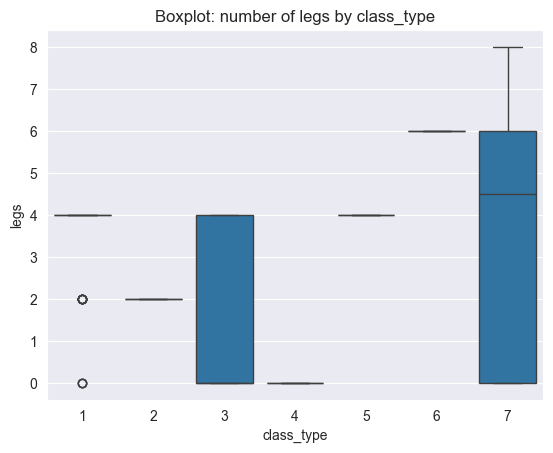

In [ ]:
plt.figure()
sns.boxplot(x='class_type', y='legs', data=zoo)
plt.title('Boxplot: number of legs by class_type')
plt.show()
plt.close()

El gráfico anterior (boxplots) muestra para cada `class_type` (1 a 7) los siguientes detalles:
- **Clase 1 (Mamíferos)**: mediana cerca de 4, IQR entre 2 y 4, sin outliers visibles. Incluye humanos (2 patas), otros mamíferos (4 patas) y delfines (0 patas).
- **Clase 2 (Aves)**: mediana en 2, IQR estrecho alrededor de 2, sin outliers. Consistente con aves de 2 patas.
- **Clase 3 (Reptiles)**: mediana entre 0 y 4, IQR que incluye 0 y 4, sin outliers. Refleja serpientes (0) y tortugas/lagartos (4).
- **Clase 4 (Peces)**: mediana en 0, IQR en 0, sin outliers ni puntos fuera de los bigotes. Confirma que no hay peces con patas.
- **Clase 5 (Anfibios)**: mediana en 4, IQR alrededor de 4, sin outliers. Consistente con ranas y salamandras.
- **Clase 6 (Insectos)**: mediana en 6, IQR estrecho alrededor de 6, sin outliers.
- **Clase 7 (Moluscos/Invertebrados)**: mediana en 0, IQR que incluye 0, con puntos fuera de los bigotes en 5 y 8. Estos son válidos (estrella de mar y pulpo).

El gráfico muestra que la mayoría de las clases tienen distribuciones consistentes con sus características biológicas (4 patas en mamíferos, 2 en aves, 6 en insectos).

# Descriptive Statistics

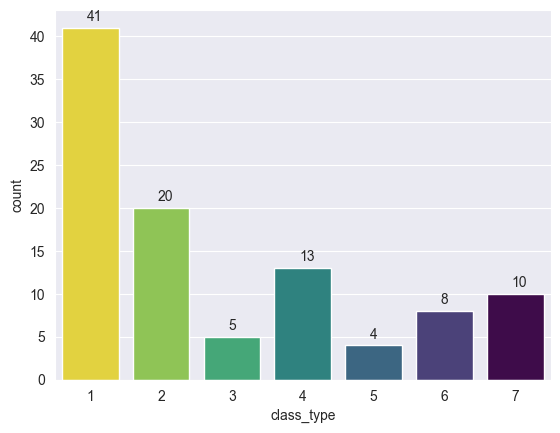

In [ ]:
plt.figure()
plt.grid(True)
ax = sns.countplot(x='class_type', hue='class_type', data=zoo, palette='viridis_r', legend=False)
for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.35, p.get_height()+0.8))

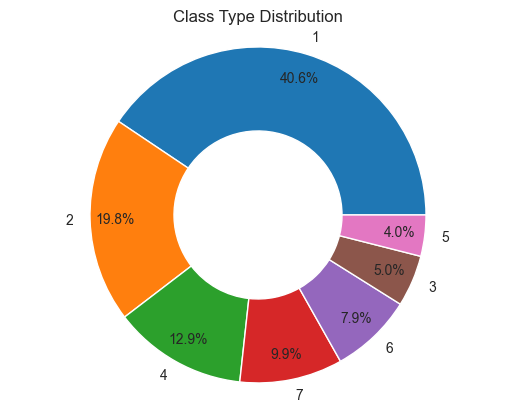

In [ ]:
def create_donut_chart(data, column_name, title):
    # Count the frequency of each class type
    value_counts = data[column_name].value_counts()

    # Create donut chart
    plt.figure()
    plt.pie(value_counts.values, labels=value_counts.index,
            autopct='%1.1f%%', pctdistance=0.85,
            wedgeprops=dict(width=0.5))
    plt.title(title)
    plt.axis('equal')
    plt.show()

# Use the function
create_donut_chart(zoo, 'class_type', 'Class Type Distribution')

Los gráficos anteriores muestran que existe una mayor distribución de la clase mamíferos.

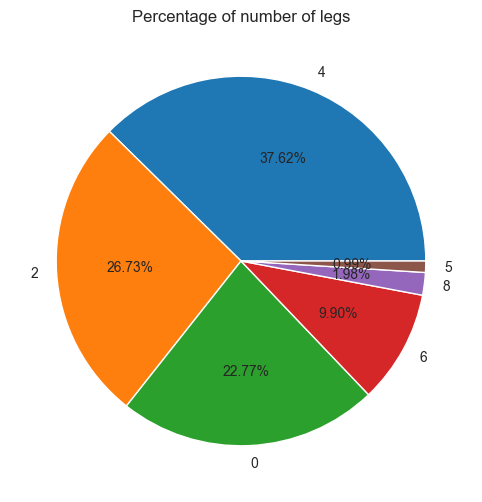

In [ ]:
# legs visualization
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
#
# # Gráfico de barras (Count plot)
# sns.countplot(data=zoo, x='legs', order=zoo['legs'].value_counts().index, ax=ax1)
# ax1.set_title("Frecuencia del número de patas")
#
# # Gráfico de pastel (Pie Chart)
# counts = zoo['legs'].value_counts()
# labels = ['4', '2', '0', '6', '8', '5']
# ax2.pie(counts, labels=labels, autopct='%.02f%%')
# ax2.set_title("Porcentaje del número de patas")
#
# plt.show()

labels = ['4', '2', '0', '6', '8', '5']  # Etiquetas personalizadas
counts = zoo['legs'].value_counts()       # Frecuencia de cada valor

# Crear el gráfico de pastel
plt.figure(figsize=(8, 6))  # Tamaño opcional
plt.pie(counts, labels=labels, autopct='%.02f%%')
plt.title("Percentage of number of legs")
plt.show()

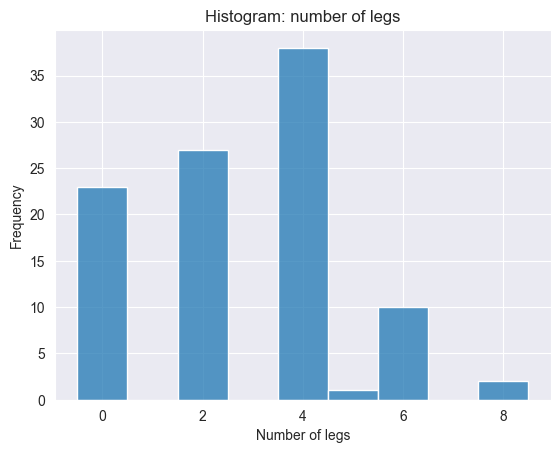

In [ ]:
plt.figure()
sns.histplot(zoo['legs'], bins=range(0, 9), discrete=True)
plt.title('Histogram: number of legs')
plt.xlabel('Number of legs')
plt.ylabel('Frequency')
plt.show()
plt.close()

Los gráficos anteriores muestran una mayor distribución hacia los animales de 4 patas, principalmente mamíferos. Concuerda con la mayor frecuencia de mamíferos. En el histograma, se puede apreciar que los datos lo cual es consistente con las categorías biológicas representadas en la base de datos: no hay animales con 1, 3 o 7 patas. La distribución no es simétrica; está sesgada hacia la derecha, lo cual es esperable, ya que biológicamente, la mayoría de los animales tienen 0, 2, o 4 patas, mientras que 5 y 8 son raros (estrella de mar, pulpo, escorpión).

Los siguientes gráficos muestran la distribución de una característica, si esta está presente o no

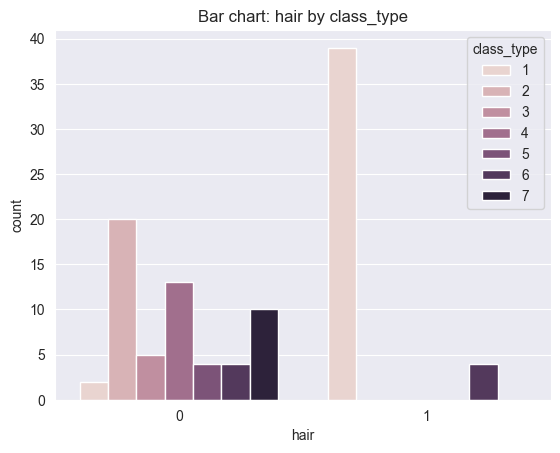

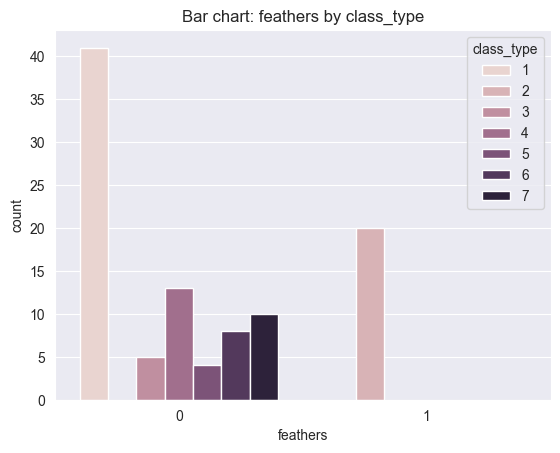

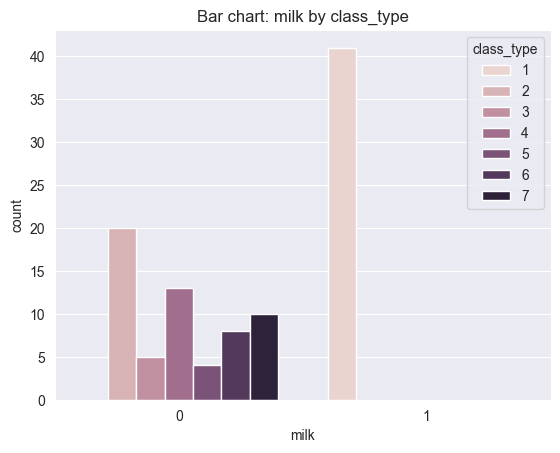

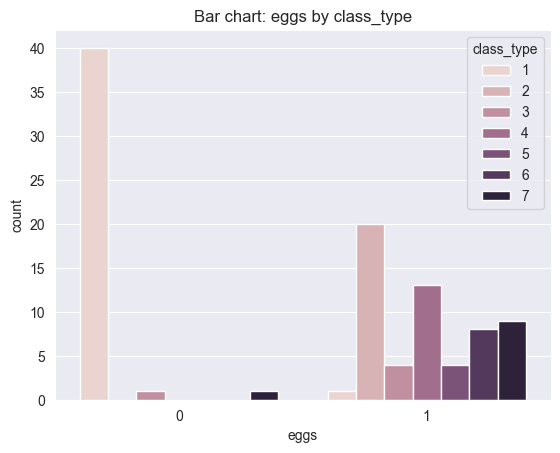

In [ ]:
# Bar chart for binary attributes (hair, feathers, milk, eggs)
binary_columns = [col for col in zoo.columns if col != 'legs' and col != 'class_type']
for col in ['hair', 'feathers', 'milk', 'eggs']:
    plt.figure()
    sns.countplot(x=col, hue='class_type', data=zoo)
    plt.title(f'Bar chart: {col} by class_type')
    plt.show()
    plt.close()

**Observaciones del Gráfico Hair**

Para `hair = 0` (sin pelo):
- Total de animales: aproximadamente 58 (suma de las alturas de las barras apiladas).
- Clase 1 (Mamíferos): ~2 animales (muy pocos mamíferos no tienen pelo).
- Clase 2 (Aves): ~20 animales (todas las aves, ya que no tienen pelo, sino plumas).
- Clase 3 (Reptiles): ~5 animales (todos los reptiles, que tienen escamas, no pelo).
- Clase 4 (Peces): ~13 animales (todos los peces, que tienen escamas o piel, no pelo).
- Clase 5 (Anfibios): ~4 animales (todos los anfibios, que tienen piel húmeda, no pelo).
- Clase 6 (Insectos): ~8 animales (todos los insectos, que tienen exoesqueleto, no pelo).
- Clase 7 (Moluscos/Invertebrados): ~9 animales (la mayoría de los moluscos/invertebrados, que tienen conchas o piel, no pelo).

Para `hair = 1` (con pelo):
- Total de animales: aproximadamente 43 (suma de las alturas de las barras apiladas).
- Clase 1 (Mamíferos): ~39 animales (la gran mayoría de los mamíferos tienen pelo).
- Clase 2 (Aves): 0 animales (las aves no tienen pelo).
- Clase 3 (Reptiles): 0 animales (los reptiles no tienen pelo).
- Clase 4 (Peces): 0 animales (los peces no tienen pelo).
- Clase 5 (Anfibios): 0 animales (los anfibios no tienen pelo).
- Clase 6 (Insectos): ~3 animales (algunos insectos como abeja y mosca tienen pelo, pero es más bien vellosidad).
- Clase 7 (Moluscos/Invertebrados): ~1 animal (posiblemente un dato atípico).

El mismo análisis anterior puede realizarse para los otros tres gráficos (feathers, milk, eggs).

In [ ]:
# Delete `animal_name` column (for the analysis is not relevant)
zoo_data = zoo.drop('animal_name', axis=1)
zoo_data.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


#### Correlations

In [ ]:
# Correlations (phi coefficient for binary attributes)
def phi_coefficient(x , y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / n)

In [ ]:
# calculate phi correlation matrix
binary_columns = [col for col in zoo_data.columns if col != 'legs' and col != 'class_type']
phi_matrix = pd.DataFrame(index=binary_columns, columns=binary_columns)
for col1 in binary_columns:
    for col2 in binary_columns:
        phi_matrix.loc[col1, col2] = phi_coefficient(zoo_data[col1], zoo_data[col2])

print("Phi correlation matrix (binary attributes):")
print(phi_matrix)

Phi correlation matrix (binary attributes):
              hair  feathers      eggs      milk  airborne   aquatic  \
hair      0.979751  0.402727  0.797068  0.858115  0.174908   0.45265   
feathers  0.402727  0.968827  0.394043  0.385464  0.627367  0.032614   
eggs      0.797068  0.394043  0.979621  0.918394  0.353047  0.355272   
milk      0.858115  0.385464  0.918394  0.979472   0.34308  0.341565   
airborne  0.174908  0.627367  0.353047   0.34308  0.972673  0.148353   
aquatic    0.45265  0.032614  0.355272  0.341565  0.148353  0.978419   
predator  0.134625  0.079436       0.0  0.009438   0.27178  0.355182   
toothed   0.472059  0.588231  0.621613  0.607556  0.570529  0.032015   
backbone  0.165519  0.198943  0.314174  0.358616  0.074326       0.0   
breathes  0.416477  0.223976  0.358026  0.398686  0.257378  0.612036   
venomous  0.067172   0.09974  0.061496   0.20512       0.0  0.049642   
fins      0.253554  0.190339   0.13795  0.129384   0.22007  0.576865   
tail      0.026074  

(17.5, -0.5)

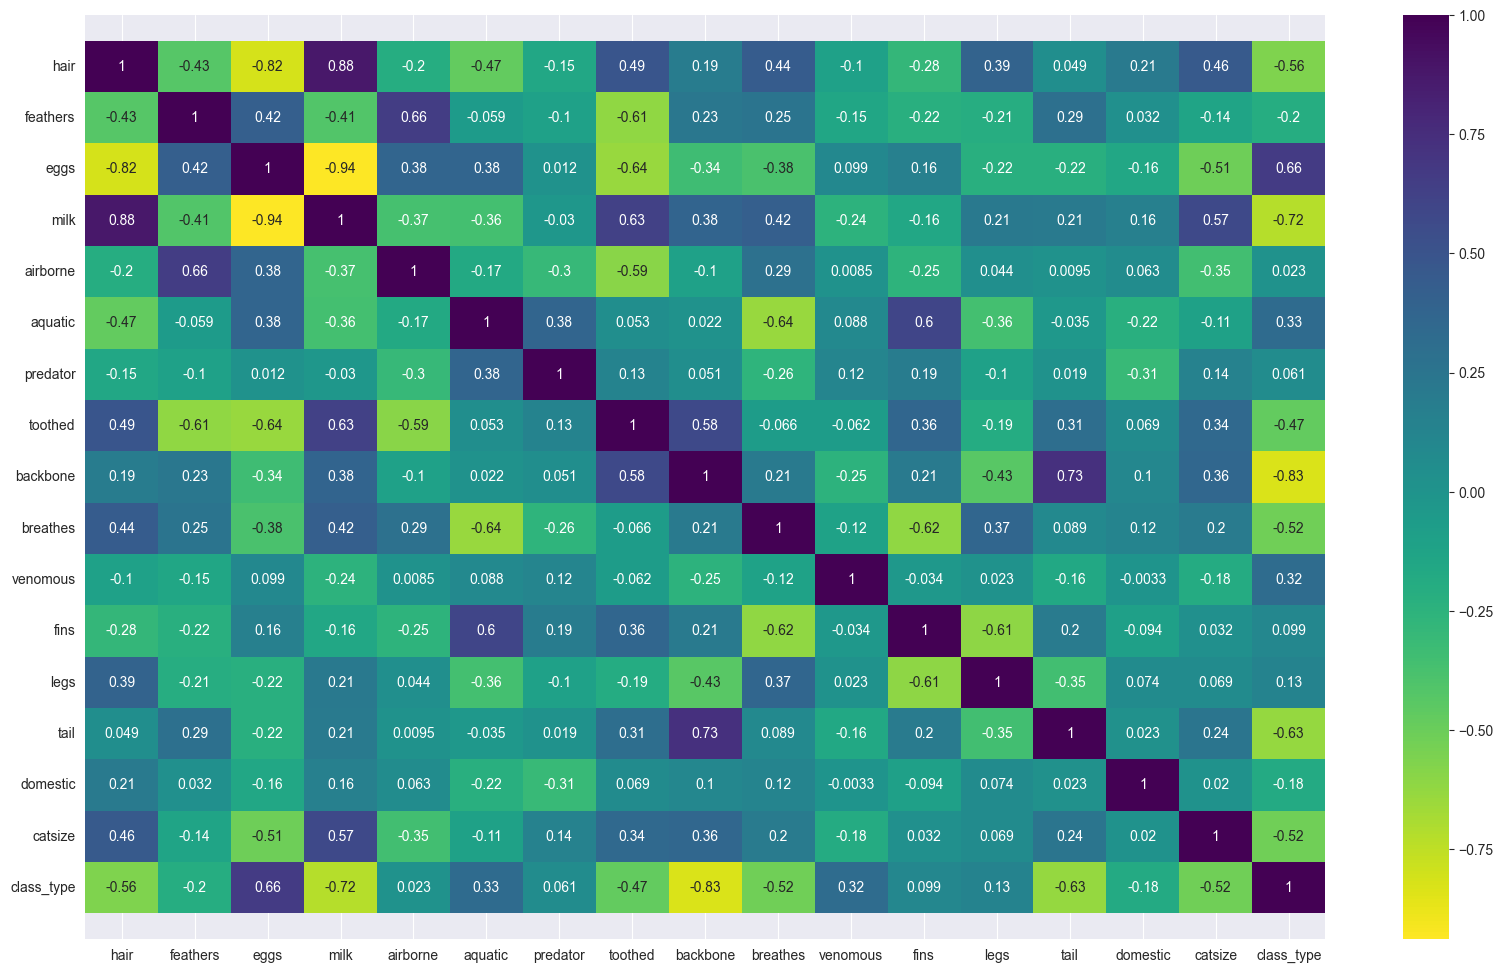

In [ ]:
# Heat map for phi correlation matrix
corr_matrix=zoo_data.corr()
plt.figure(figsize=(20,12))
ax = sns.heatmap(corr_matrix, annot = True, cmap="viridis_r")
top, bottom = ax.get_ylim()
ax.set_ylim(top+0.5, bottom-0.5)

El mapa de calor complementa el análisis estadístico previo al permitir visualizar de forma rápida qué atributos están más relacionados entre sí, lo que puede ser útil para reducir dimensionalidad o entender mejor los patrones en el dataset. La matriz de correlación presenta datos consistentes a lo que se espera. Existe una fuerte correlación entre tener pelo y producir leche. Existe una correlación negativa entre tener plumas y producir leche. Además, permite identificar relaciones o redundancias entre las características. Por ejemplo:
- Si ciertas características están altamente correlacionadas, podrían representar la misma información.
- Puede revelar grupos de atributos que tienden a aparecer juntos en ciertas clases de animales.

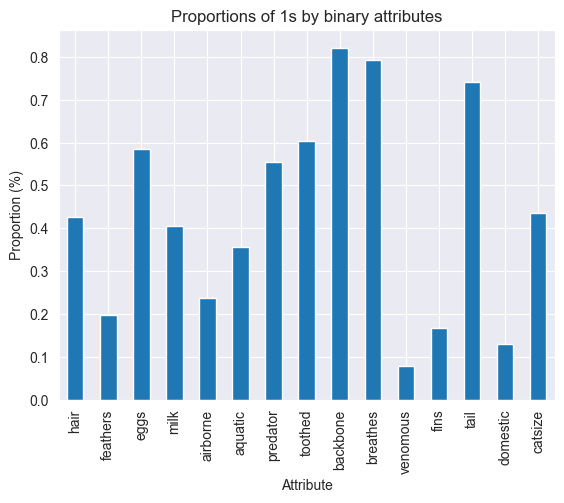

In [ ]:
# Proportions of ones by binary attributes
binary_cols = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'tail', 'domestic', 'catsize']
proportions = zoo_data[binary_cols].mean()
proportions.plot(kind='bar', color='#1f77b4')
plt.title('Proportions of 1s by binary attributes')
plt.ylabel('Proportion (%)')
plt.xlabel('Attribute')
plt.show()

# Inferential Statistics
Se aplica prueba estadística llamada Z-test para dos proporciones. Sirve para comparar si existe una diferencia significativa entre dos proporciones. En este caso, se compara la proporción de animales acuáticos entre dos grupos: mamíferos y aves.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
mammals_aquatic = zoo_data[zoo_data['class_type'] == 1]['aquatic'].sum()
birds_aquatic = zoo_data[zoo_data['class_type'] == 2]['aquatic'].sum()
n_mammals = len(zoo_data[zoo_data['class_type'] == 1])
n_birds = len(zoo_data[zoo_data['class_type'] == 2])
stats, p_val = proportions_ztest([mammals_aquatic, birds_aquatic], [n_mammals, n_birds])
print(stats, p_val)

-1.417228487353346 0.15641613548582736


**Resultado obtenido**
- Estadístico z (-1.417): indica la magnitud de la diferencia entre las proporciones de animales acuáticos en mamíferos y aves, en términos de desviaciones estándar. Un valor negativo sugiere que la proporción de animales acuáticos en mamíferos es menor que en aves, aunque la magnitud no es muy grande.
- p-valor (0.1564): este valor representa la probabilidad de obtener un resultado al menos tan extremo como el observado, bajo la hipótesis nula (que las proporciones son iguales). Dado que el p-valor es mayor que el umbral común de significancia (0.05), no se rechaza la hipótesis nula. Esto implica que no hay evidencia suficiente para concluir que la proporción de animales acuáticos difiere significativamente entre mamíferos y aves.

#### Fisher Test
Evaluar la asociación entre la presencia de columna vertebral (`backbone`) y el tipo de clase, comparando mamíferos (clase 1) e invertebrados (clase 7). El objetivo es determinar si la presencia o ausencia de columna vertebral está significativamente asociada con estas dos clases.

In [ ]:
# a Test de Fisher: backbone proportion between mammals and invertebrate
# Filtrar solo mamíferos (clase 1) e invertebrados (clase 7)
subset = zoo_data[zoo_data['class_type'].isin([1, 7])]

# Crear la tabla de contingencia
contingency_table = pd.crosstab(subset['class_type'], subset['backbone'])

# Imprimir la tabla para verificar
print("Tabla de contingencia:")
print(contingency_table)

# Aplicar el test de Fisher
_, p_value = fisher_exact(contingency_table)
print(f"Test de Fisher (backbone, mamíferos vs invertebrados): p-valor = {p_value:.4f}")

Tabla de contingencia:
backbone     0   1
class_type        
1            0  41
7           10   0
Test de Fisher (backbone, mamíferos vs invertebrados): p-valor = 0.0000


**Resultado obtenido**

La tabla muestra que todos los mamíferos (41) tienen columna vertebral (`backbone = 1`), y todos los invertebrados (10) no la tienen (`backbone = 0`).

Existe una asociación estadísticamente entre la presencia de columna vertebral y las clases de mamíferos e invertebrados. Biológicamente, es lo se espera, ya que los mamíferos tienen columna vertebral (vertebrados) y los invertebrados, por definición, carecen de ella.

#### Analysis of Variance (ANOVA)
Comparación del número de patas (`legs`) entre las siete clases de animales. El objetivo es determinar si hay diferencias significativas en el número promedio de patas entre las clases.

In [ ]:
# b. ANOVA for `legs`
anova_result = f_oneway(
    zoo_data[zoo_data['class_type'] == 1]['legs'],
    zoo_data[zoo_data['class_type'] == 2]['legs'],
    zoo_data[zoo_data['class_type'] == 3]['legs'],
    zoo_data[zoo_data['class_type'] == 4]['legs'],
    zoo_data[zoo_data['class_type'] == 5]['legs'],
    zoo_data[zoo_data['class_type'] == 6]['legs'],
    zoo_data[zoo_data['class_type'] == 7]['legs']
)

print(f"\nANOVA for legs between classes: F = {anova_result.statistic:.2f}, p-value = {anova_result.pvalue:.4f}")


ANOVA for legs between classes: F = 19.77, p-value = 0.0000


**Resultado obtenido**
- El estadístico F (19.77), mide la relación entre la variabilidad entre grupos (diferencias entre las medias de `legs` de las clases) y la variabilidad dentro de los grupos. Un valor alto sugiere que las diferencias entre las medias de las clases son grandes en comparación con la variabilidad dentro de cada clase.
- p-valor (0.0000). Un p-valor menor a 0.05 indica que se rechaza la hipótesis nula de que las medias de `legs` son iguales para todas las clases. Sugiere que al menos una clase tiene un número promedio de patas diferente.

Hay diferencias estadísticas en el número de patas entre las siete clases de animales. Por ejemplo, los mamíferos (clase 1) tienden a tener 4 patas, las aves (clase 2) 2 patas y algunos invertebrados (clase 7) pueden tener más (como insectos con 6 patas), lo que puede explicar las diferencias observadas.

#### Chi-square Test
El propósito es evaluar la asociación entre la producción de leche (`milk`) y el tipo de clase (`class_type`). El objetivo es determinar si la presencia o ausencia de producción de leche está significativamente asociada con las clases de animales.

In [ ]:
# c chi square test: association between `milk` and `class_type`
contingency_table = pd.crosstab(zoo_data['milk'], zoo_data['class_type'])
chi2, p_value, _, _ = chi2_contingency(contingency_table)

print(f"\nChi square test (milk vs class_type): chi2 = {chi2:.2f}, p-value = {p_value:.4f}")


Chi square test (milk vs class_type): chi2 = 101.00, p-value = 0.0000


**Resultado obtenido**

- Estadístico Chi-cuadrado (101.00): un valor alto indica una gran discrepancia entre las frecuencias observadas y las esperadas bajo la hipótesis nula de independencia entre milk y class_type. Puede sugerir una fuerte asociación.
- Un p-valor menor a 0.05 indica que se rechaza la hipótesis nula de que `milk` y `class_type` son independientes.

Existe una asociación estadística entre la producción de leche y el tipo de clase. Concuerda con la biología, ya que solo los mamíferos (clase 1) producen leche, mientras que las otras clases (aves, reptiles, etc.) no lo hacen, lo que genera una fuerte relación.

### PCA
Se estandariza la columna `legs` para que tenga media 0 y varianza 1, asegurando que no domine el PCA debido a su escala.

El DataFrame `X` queda listo para el PCA, con todas las características en una escala comparable.

In [ ]:
# Separate features and `legs` standardization
X = zoo_data.drop('class_type', axis=1)
scaler = StandardScaler()
X['legs'] = scaler.fit_transform(X[['legs']])
X

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,0.572540,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,0.572540,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,-1.404435,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,0.572540,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,0.572540,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,1,0,0,0,1,1,1,0,0,-0.415948,1,0,1
97,1,0,1,0,1,0,0,0,0,1,1,0,1.561027,0,0,0
98,1,0,0,1,0,0,1,1,1,1,0,0,0.572540,1,0,1
99,0,0,1,0,0,0,0,0,0,1,0,0,-1.404435,0,0,0


Propósito:
Aplicar el análisis de componentes principales (PCA) para reducir la dimensionalidad de las 16 características a 5 componentes principales, y calcular la varianza explicada por cada componente.

In [ ]:
# Applying PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X)
explained_variance = pca.explained_variance_ratio_

print("Variance explained by components: ", explained_variance)
print("Cumulative variance:", np.cumsum(explained_variance))

Variance explained by components:  [0.34917921 0.24901864 0.12571385 0.06845911 0.04109432]
Cumulative variance: [0.34917921 0.59819785 0.7239117  0.79237082 0.83346513]


**Resultado obtenido**
- Varianza explicada. El primer componente (PC1) explica el 34.92% de la varianza total, el segundo (PC2) el 24.90% (PC1 (34.92%), PC2 (24.90%), PC3 (12.57%), PC4 (6.85%), PC5 (4.11%)). Los cinco componentes explican el 83.35% de la varianza, lo que indica que capturan la mayor parte de la variabilidad en los datos con una reducción significativa de dimensionalidad (de 16 a 5 dimensiones).
- Varianza acumulada. Con 5 componentes, se captura el 83.35% de la información, lo que sugiere que el PCA es efectivo para resumir los datos sin perder demasiada información.

Lo anterior, facilita la visualización y el análisis de los datos mientras se conserva la mayor parte de la información.

#### Attribute loadings in principal components
El propósito es identificar qué variables contribuyen más a cada componente.

In [ ]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(5)])

print("\nAttribute loadings in principal components:")
print(loadings)


Attribute loadings in principal components:
               PC1       PC2       PC3       PC4       PC5
hair      0.302225  0.285340 -0.065258 -0.145082 -0.100356
feathers -0.104993 -0.155265 -0.390460  0.348279  0.049744
eggs     -0.240721 -0.375534  0.029827  0.040370  0.106937
milk      0.241751  0.385878 -0.051166 -0.020974 -0.100626
airborne -0.022539 -0.233039 -0.375558  0.066932  0.045828
aquatic  -0.238633 -0.020488  0.388917  0.148952  0.387802
predator -0.078893  0.066521  0.394046  0.619184 -0.396580
toothed   0.023801  0.430998  0.176137 -0.176286  0.203654
backbone -0.074214  0.271066 -0.212797  0.212654  0.282169
breathes  0.196247  0.027818 -0.357049  0.131050 -0.199907
venomous -0.011060 -0.048865  0.081663 -0.058448 -0.112243
fins     -0.208952  0.124189  0.193293 -0.088885  0.261715
legs      0.777685 -0.359271  0.240252  0.184509  0.378910
tail     -0.087854  0.218799 -0.264883  0.308396  0.483400
domestic  0.048189  0.029114 -0.128082 -0.202409  0.187806
catsize   0

**Resultado obtenido**
- PC1: dominado por `legs` (0.777685), seguido de `hair` (0.302225) y `milk` (0.241751). Sugiere que PC1 captura principalmente la variación asociada con el número de patas y características típicas de los mamíferos.
- PC2: Influenciado por `toothed` (0.430998), `milk` (0.385878), y `legs` (-0.359271). PC2 parece distinguir entre animales con dientes y leche (mamíferos) y aquellos con diferente número de patas.
- PC3: Influenciado por `predator` (0.394046), `aquatic` (0.388917), y `feathers` (-0.390460), sugiere una distinción entre depredadores acuáticos y aves.
- PC4 y PC5: Tienen contribuciones más equilibradas, con `predator` (0.619184) y `tail` (0.483400) destacando, respectivamente.

Los signos positivos o negativos indican la dirección de la relación. Por ejemplo, en PC1, `legs` tiene una carga positiva, mientras que `eggs` y `aquatic` tienen cargas negativas, lo que sugiere que animales con más patas tienden a no poner huevos ni ser acuáticos.

#### Visualization PC1 vs PC2
Gráfico de dispersión de los dos primeros componentes principales (PC1 vs. PC2), para explorar cómo se agrupan las clases en el espacio reducido.

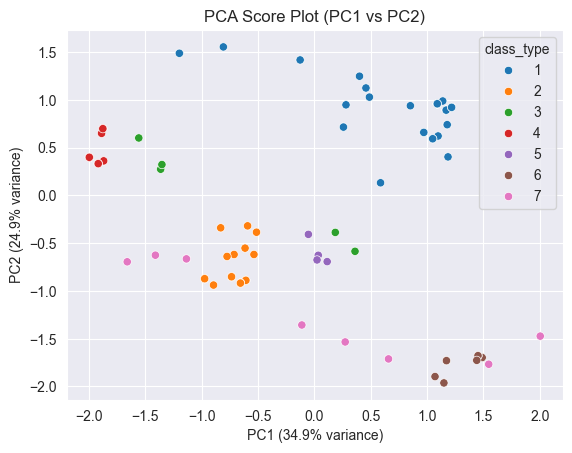

In [ ]:
plt.figure()
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=zoo_data['class_type'], palette='tab10')
plt.title('PCA Score Plot (PC1 vs PC2)')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)')
plt.show()
plt.close()

**Resultado obtenido**

El gráfico muestra cómo los animales se distribuyen en el espacio de PC1 y PC2, que juntos explican el 59.8% de la varianza (34.9% + 24.9%).

Indica que las características capturadas por PC1 y PC2 (como `legs`, `hair`, `milk`, `toothed`) pueden ser efectivas para distinguir entre clases. De este modo, los mamíferos (clase 1) probablemente se agrupen en una región debido a su alta 'carga' en `milk` y `hair`, en cambio, las aves (clase 2) podrían agruparse por `feathers`.

#### Identification of more informative variables
El objetivo es determinar qué variables contribuyen más a la variabilidad capturada por el PCA.

In [ ]:
important_features = loadings.abs().sum(axis=1).sort_values(ascending=False)

print("\nMore informative attributes (sums of absolute charges in PCs):")
print(important_features)


More informative attributes (sums of absolute charges in PCs):
legs        1.940627
predator    1.555225
tail        1.363332
aquatic     1.184792
backbone    1.052899
feathers    1.048741
toothed     1.010877
breathes    0.912072
hair        0.898261
catsize     0.880264
fins        0.877033
milk        0.800395
eggs        0.793389
airborne    0.743896
domestic    0.595599
venomous    0.312279
dtype: float64


**Resultado obtenido**
La variable `legs` tiene la mayor suma de cargas absolutas (1.940627), indicando que es la característica que más contribuye a la variabilidad capturada por los cinco componentes. Le siguen `predator` (1.555225), `tail` (1.363332), `aquatic` (1.184792), `backbone` (1.052899).

El significado biológico de estas características es clave para distinguir entre clases de animales:
- `legs`: varía entre clases (mamíferos con 4, aves con 2, insectos con 6, etc.).
- `predator`: diferencia entre animales depredadores y no depredadores.
- `tail` y `aquatic`: reflejan características que son distintivas de ciertas clases (como peces o reptiles acuáticos).
- `backbone` y `feathers`: son específicas de vertebrados y aves, respectivamente.